In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

tx = pd.read_csv("../data/processed/clean_investor_transactions.csv")

perf = pd.read_csv("../data/processed/clean_scheme_performance.csv")

print("NAV Columns")
print(nav.columns)

print("\nTransaction Columns")
print(tx.columns)

print("\nPerformance Columns")
print(perf.columns)

NAV Columns
Index(['amfi_code', 'date', 'nav'], dtype='str')

Transaction Columns
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

Performance Columns
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [2]:
print(nav.head())

print("\n")
print(tx.head())

print("\n")
print(perf.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [4]:
tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

print(tx["transaction_date"].min())
print(tx["transaction_date"].max())

2024-01-01 00:00:00
2025-05-30 00:00:00


In [5]:
from pathlib import Path

charts_dir = Path("../reports/charts")
charts_dir.mkdir(exist_ok=True)

## NAV Trend Analysis (2022–2026)


In [6]:
nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.15
)

fig.show()

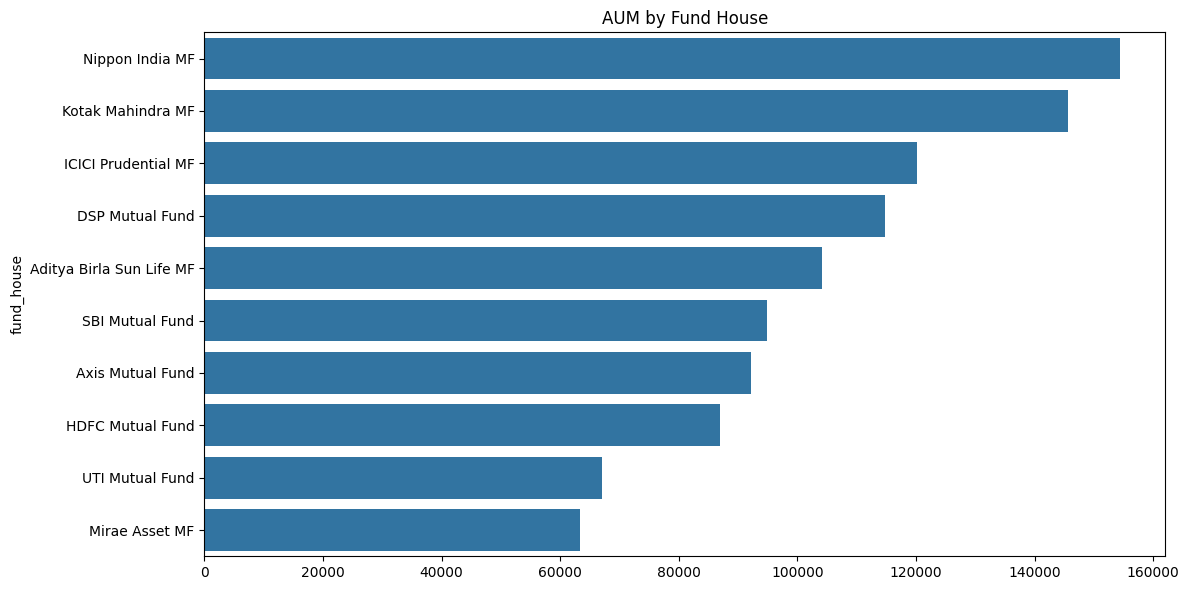

In [7]:
perf["aum_crore"] = pd.to_numeric(
    perf["aum_crore"]
)

plt.figure(figsize=(12,6))

fund_aum = (
    perf.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=fund_aum.values,
    y=fund_aum.index
)

plt.title("AUM by Fund House")
plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_house_aum.png"
)

plt.show()

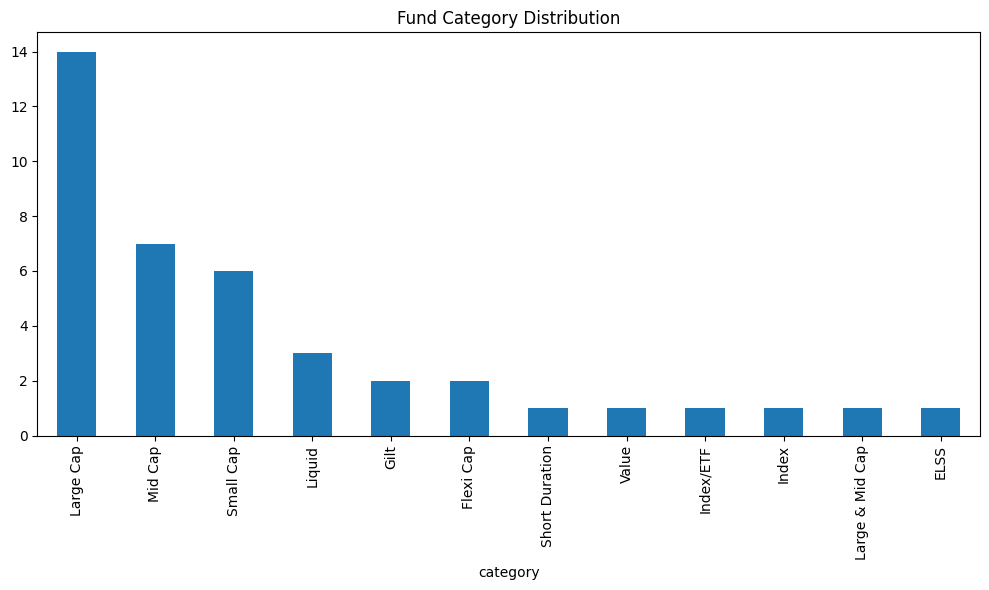

In [8]:
plt.figure(figsize=(10,6))

perf["category"].value_counts().plot(
    kind="bar"
)

plt.title("Fund Category Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_distribution.png"
)

plt.show()

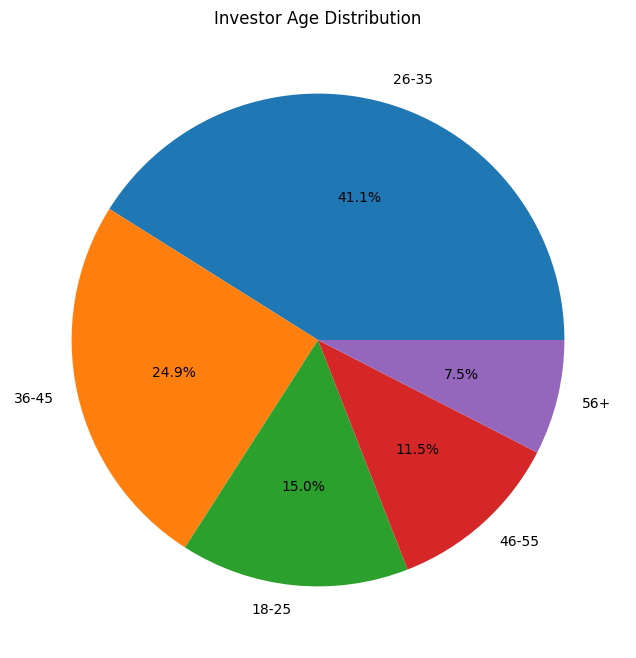

In [9]:
age_counts = tx["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.savefig(
    "../reports/charts/age_distribution.png"
)

plt.show()

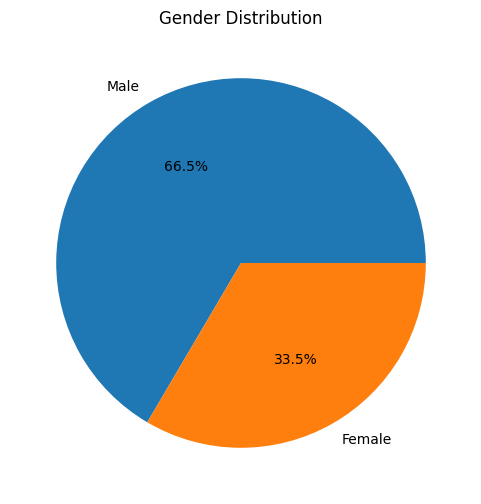

In [10]:
gender = tx["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png"
)

plt.show()

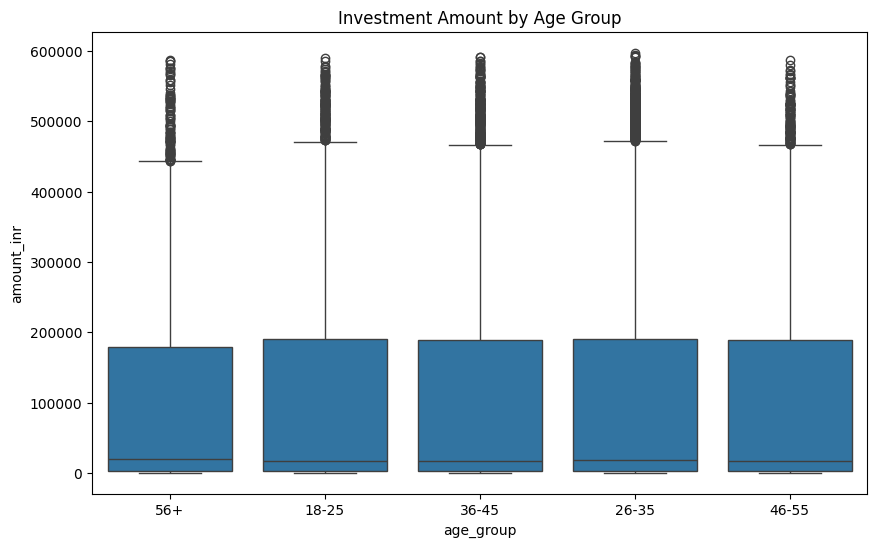

In [11]:
tx["amount_inr"] = pd.to_numeric(
    tx["amount_inr"]
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=tx,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig(
    "../reports/charts/age_boxplot.png"
)

plt.show()

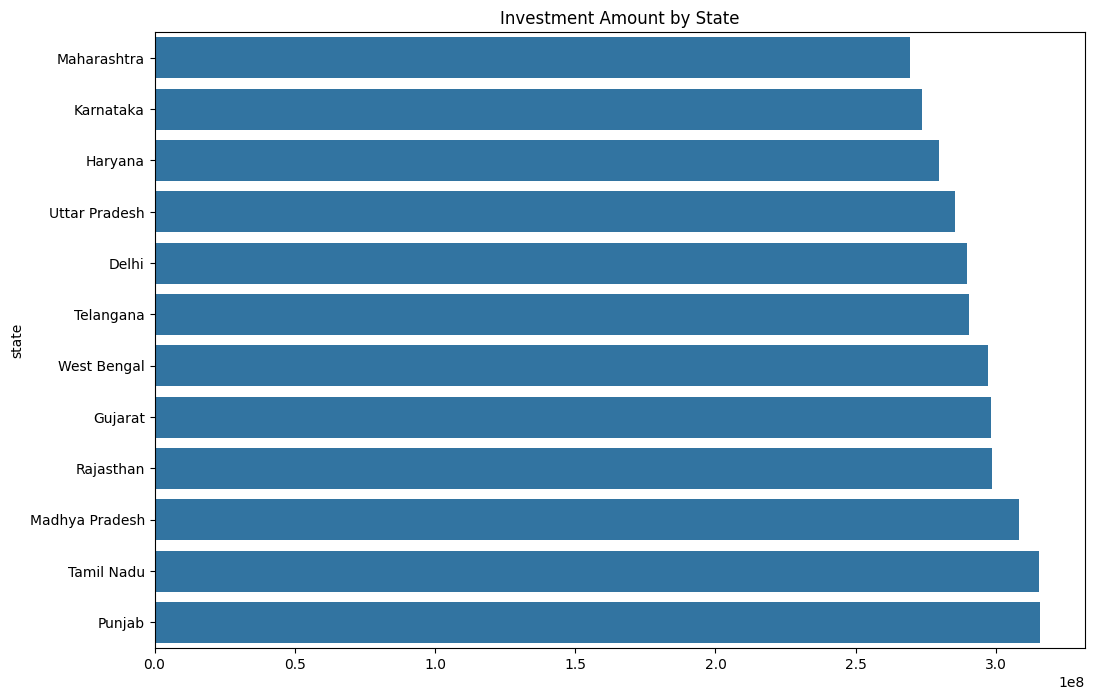

In [12]:
state_amount = (
    tx.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Investment Amount by State")

plt.savefig(
    "../reports/charts/state_distribution.png"
)

plt.show()

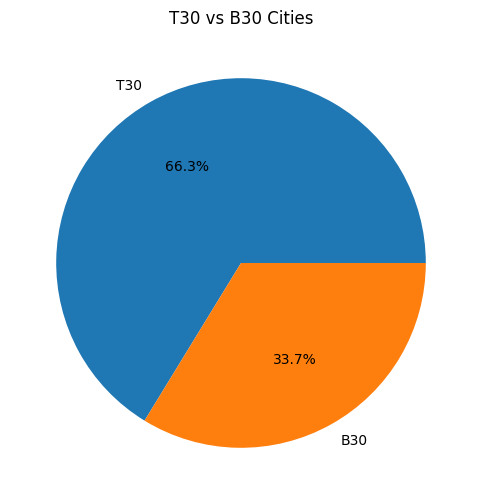

In [13]:
city = tx["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city,
    labels=city.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Cities")

plt.savefig(
    "../reports/charts/t30_b30.png"
)

plt.show()

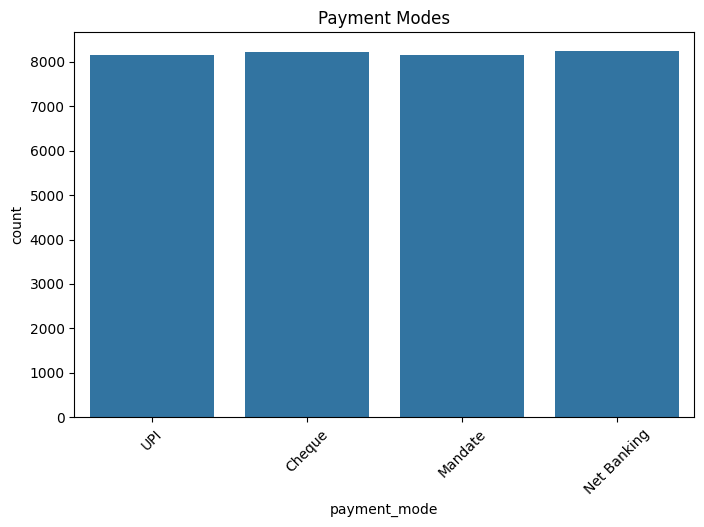

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=tx,
    x="payment_mode"
)

plt.title("Payment Modes")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/charts/payment_mode.png"
)

plt.show()

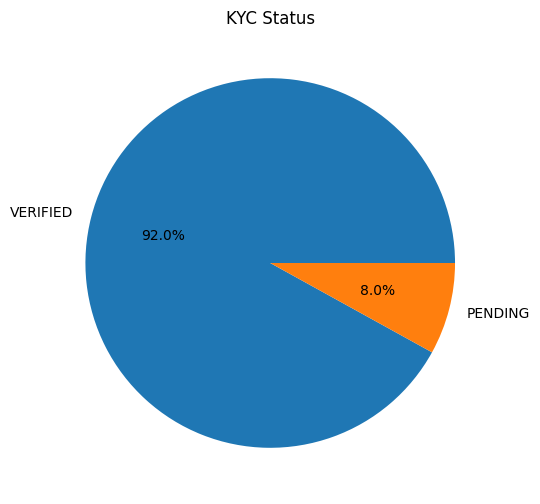

In [15]:
plt.figure(figsize=(6,6))

tx["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("KYC Status")

plt.ylabel("")

plt.savefig(
    "../reports/charts/kyc_status.png"
)

plt.show()

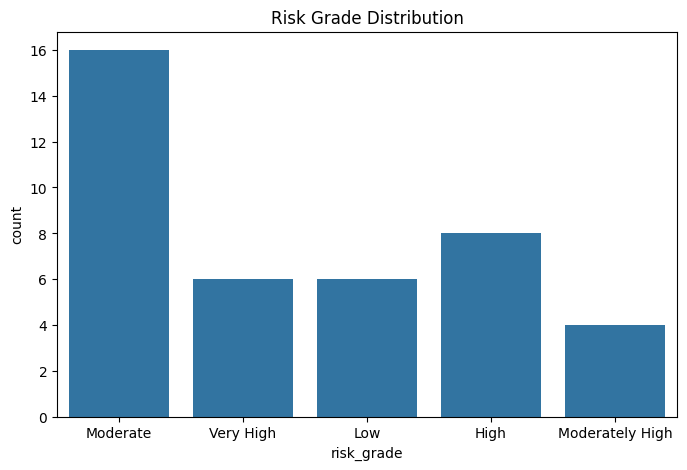

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=perf,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.savefig(
    "../reports/charts/risk_grade.png"
)

plt.show()

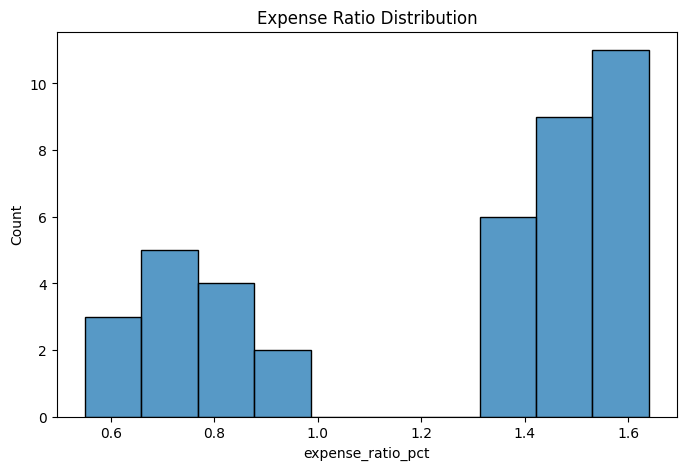

In [17]:
perf["expense_ratio_pct"] = pd.to_numeric(
    perf["expense_ratio_pct"]
)

plt.figure(figsize=(8,5))

sns.histplot(
    perf["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")

plt.savefig(
    "../reports/charts/expense_ratio.png"
)

plt.show()

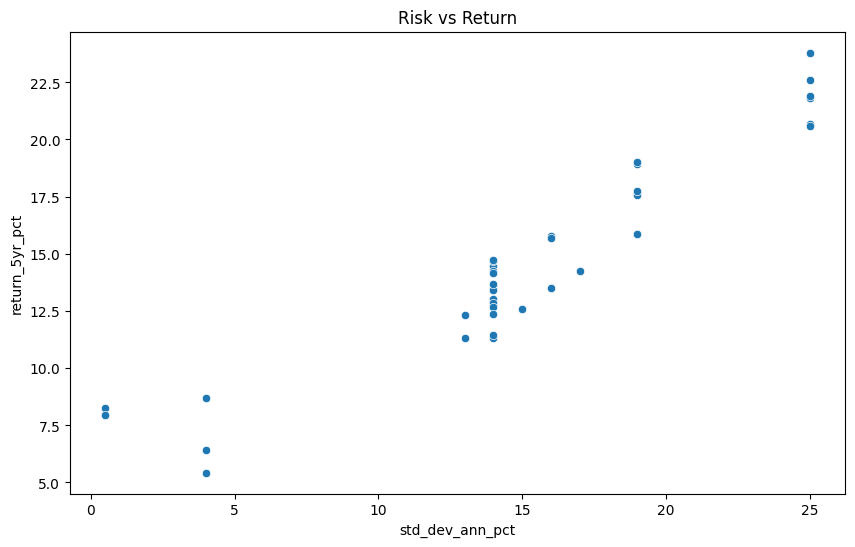

In [18]:
perf["return_5yr_pct"] = pd.to_numeric(
    perf["return_5yr_pct"]
)

perf["std_dev_ann_pct"] = pd.to_numeric(
    perf["std_dev_ann_pct"]
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf,
    x="std_dev_ann_pct",
    y="return_5yr_pct"
)

plt.title("Risk vs Return")

plt.savefig(
    "../reports/charts/risk_return.png"
)

plt.show()

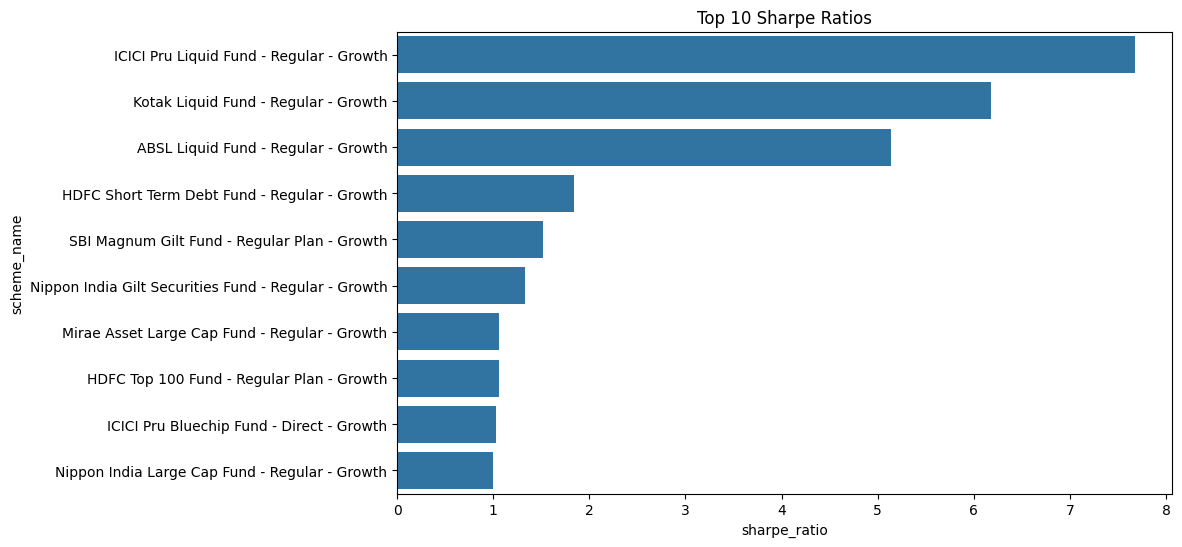

In [19]:
perf["sharpe_ratio"] = pd.to_numeric(
    perf["sharpe_ratio"]
)

top_sharpe = (
    perf.sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Sharpe Ratios")

plt.savefig(
    "../reports/charts/top_sharpe.png"
)

plt.show()

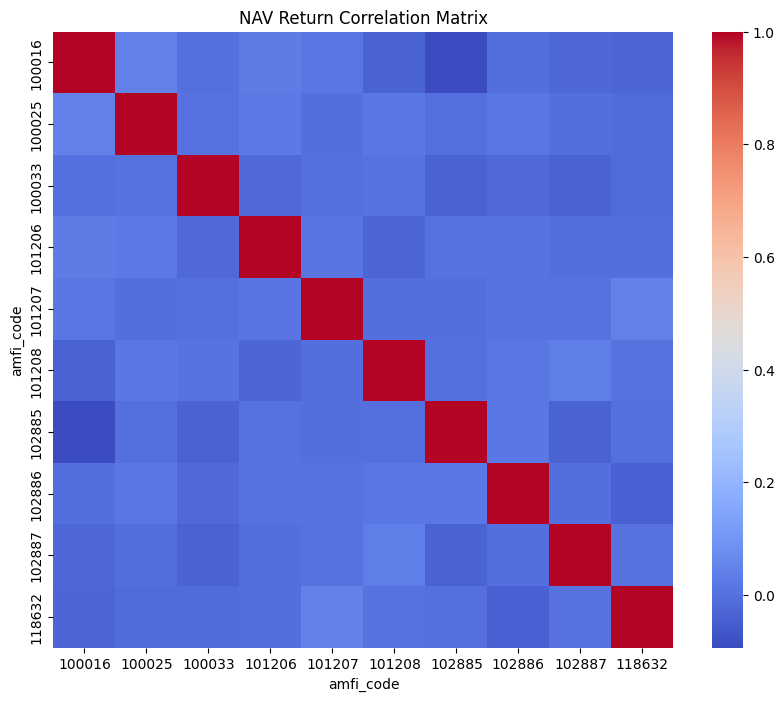

In [20]:
pivot_nav = (
    nav.pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

returns = pivot_nav.pct_change()

corr = (
    returns.iloc[:, :10]
    .corr()
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.savefig(
    "../reports/charts/correlation_matrix.png"
)

plt.show()

# Key EDA Findings

## Finding 1
Daily NAV values across schemes showed a consistent upward trend from 2022 to 2026, indicating long-term wealth creation potential.

## Finding 2
The strongest NAV growth period was observed during 2023, reflecting favorable market conditions and a broad bull run.

## Finding 3
Several schemes experienced temporary corrections during 2024, but recovered quickly, demonstrating resilience.

## Finding 4
AUM distribution is highly concentrated among a few large fund houses, indicating strong brand trust and market leadership.

## Finding 5
Equity-oriented categories dominate the scheme universe, reflecting investor preference for growth-oriented investments.

## Finding 6
The 26–35 and 36–45 age groups contribute a significant share of mutual fund investments, representing the core investor segment.

## Finding 7
SIP investments are more common than lump-sum investments, highlighting the popularity of disciplined investing.

## Finding 8
T30 cities account for a larger proportion of investments compared to B30 cities, reflecting higher financial penetration in metro regions.

## Finding 9
Most investors have completed KYC verification, indicating strong regulatory compliance.

## Finding 10
The correlation matrix shows positive relationships among most mutual fund schemes, suggesting exposure to common market factors.

# Conclusion

The exploratory analysis of mutual fund data reveals strong long-term growth in NAV, increasing investor participation, and concentration of assets among leading fund houses.

Investor demographics indicate that working-age groups form the majority of mutual fund investors, while T30 cities continue to dominate investment activity.

Performance metrics such as Sharpe Ratio, Risk Grade, and Expense Ratio provide useful insights into fund quality and risk-adjusted returns.

Overall, the dataset demonstrates healthy growth in the mutual fund ecosystem and provides a strong foundation for further predictive analytics and portfolio optimization.

In [21]:
import os

charts = os.listdir("../reports/charts")
print("Total Charts:", len(charts))

for c in charts:
    print(c)

Total Charts: 14
age_boxplot.png
age_distribution.png
category_distribution.png
correlation_matrix.png
expense_ratio.png
fund_house_aum.png
gender_distribution.png
kyc_status.png
payment_mode.png
risk_grade.png
risk_return.png
state_distribution.png
t30_b30.png
top_sharpe.png


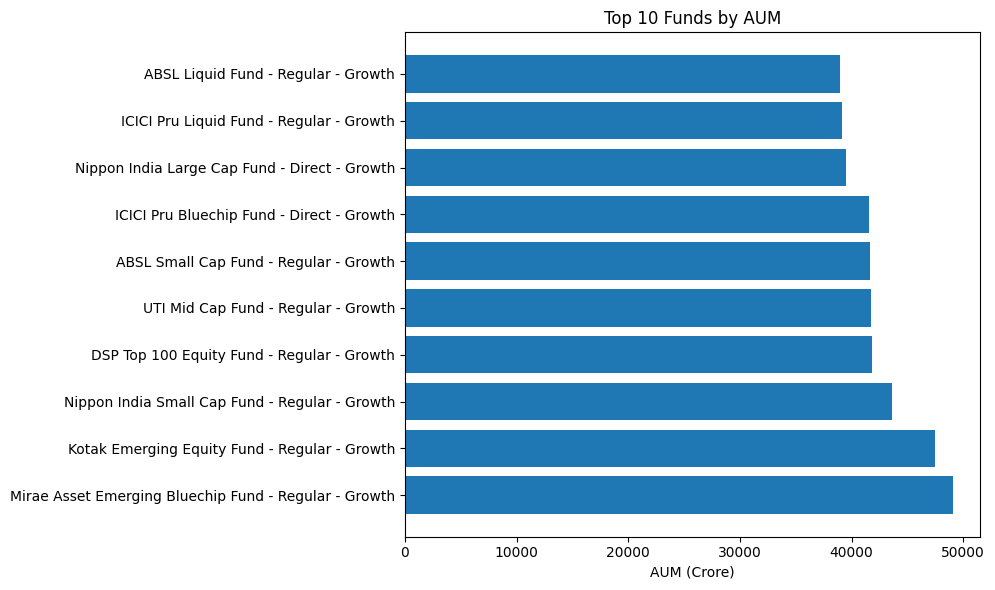

In [22]:
import matplotlib.pyplot as plt

top_aum = perf.sort_values("aum_crore", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_aum["scheme_name"], top_aum["aum_crore"])
plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.tight_layout()

plt.savefig("../reports/charts/top_10_aum.png")
plt.show()

In [23]:
import os
print(len(os.listdir("../reports/charts")))

15
